# Création d'une session Spark

In [2]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
        .appName('Gestion_Logistique')
        .master('local[*]')
        .getOrCreate())

# Chargement des données brutes

In [4]:
df = spark.read.csv('DataCoSupplyChainDataset.csv', header = True, inferSchema = True)

In [5]:
df.show(100)

+--------+------------------------+-----------------------------+-----------------+------------------+-----------------+------------------+-----------+----------------+--------------+----------------+--------------+--------------+-----------+--------------+-----------------+----------------+--------------+--------------------+----------------+-------------+---------------+-----------+------------+------------+-------------+--------------------+-----------------+-----------------------+--------+----------------------+-------------------+------------------------+-------------+------------------------+-----------------------+-------------------+-----------+----------------+----------------------+---------------+--------------------+---------------+-------------+---------------+-------------------+-------------------+--------------------+--------------------+-------------+--------------+--------------------------+--------------+
|    Type|Days for shipping (real)|Days for shipment (schedul

# Détection des colonnes dupliquées

In [6]:
from pyspark.sql import functions as F

def find_identical_columns(df):
    same_value_pairs = []
    columns = df.columns
    
    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            col1, col2 = columns[i], columns[j]
            diff_count = df.filter(
                (F.col(col1).isNotNull() & F.col(col2).isNull()) |
                (F.col(col1).isNull() & F.col(col2).isNotNull()) |
                (F.col(col1).cast("string") != F.col(col2).cast("string"))
            ).count()
            
            if diff_count == 0:
                same_value_pairs.append((col1, col2))
                print(f"✓ {col1} == {col2}")
    
    return same_value_pairs

identical_pairs = find_identical_columns(df)
print("\nPairs of columns with identical values:")
for pair in identical_pairs:
    print(pair)


✓ Benefit per order == Order Profit Per Order
✓ Sales per customer == Order Item Total
✓ Category Id == Product Category Id
✓ Customer Email == Customer Password
✓ Customer Id == Order Customer Id
✓ Order Item Cardprod Id == Product Card Id
✓ Order Item Product Price == Product Price

Pairs of columns with identical values:
('Benefit per order', 'Order Profit Per Order')
('Sales per customer', 'Order Item Total')
('Category Id', 'Product Category Id')
('Customer Email', 'Customer Password')
('Customer Id', 'Order Customer Id')
('Order Item Cardprod Id', 'Product Card Id')
('Order Item Product Price', 'Product Price')


# Affichage du schéma des colonnes

In [7]:
df.printSchema()

root
 |-- Type: string (nullable = true)
 |-- Days for shipping (real): integer (nullable = true)
 |-- Days for shipment (scheduled): integer (nullable = true)
 |-- Benefit per order: double (nullable = true)
 |-- Sales per customer: double (nullable = true)
 |-- Delivery Status: string (nullable = true)
 |-- Late_delivery_risk: integer (nullable = true)
 |-- Category Id: integer (nullable = true)
 |-- Category Name: string (nullable = true)
 |-- Customer City: string (nullable = true)
 |-- Customer Country: string (nullable = true)
 |-- Customer Email: string (nullable = true)
 |-- Customer Fname: string (nullable = true)
 |-- Customer Id: integer (nullable = true)
 |-- Customer Lname: string (nullable = true)
 |-- Customer Password: string (nullable = true)
 |-- Customer Segment: string (nullable = true)
 |-- Customer State: string (nullable = true)
 |-- Customer Street: string (nullable = true)
 |-- Customer Zipcode: integer (nullable = true)
 |-- Department Id: integer (nullable = 

# Affichage d'un extrait des données

In [8]:
df.show(5)

+--------+------------------------+-----------------------------+-----------------+------------------+----------------+------------------+-----------+--------------+-------------+----------------+--------------+--------------+-----------+--------------+-----------------+----------------+--------------+--------------------+----------------+-------------+---------------+-----------+------------+------------+----------+-------------+-----------------+-----------------------+--------+----------------------+-------------------+------------------------+-------------+------------------------+-----------------------+-------------------+------+----------------+----------------------+--------------+---------------+---------------+-------------+---------------+-------------------+-------------------+--------------------+------------+-------------+--------------+--------------------------+--------------+
|    Type|Days for shipping (real)|Days for shipment (scheduled)|Benefit per order|Sales per c

# Affichage des Statistiques descriptives globales

In [9]:
df.describe().show()

+-------+--------+------------------------+-----------------------------+------------------+------------------+----------------+-------------------+------------------+------------------+-------------+----------------+--------------+--------------+-----------------+--------------+-----------------+----------------+------------------+---------------+-----------------+-----------------+---------------+-----------------+------------------+------+--------------+-------------+-----------------+-----------------------+-----------------+----------------------+-------------------+------------------------+------------------+------------------------+-----------------------+-------------------+------------------+------------------+----------------------+--------------+--------------+---------------+------------------+-----------------+-------------------+-------------------+--------------------+--------------------+------------------+--------------+--------------------------+--------------+
|summa

# Identification des valeurs manquantes

In [10]:
from pyspark.sql import functions as F

missing_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
])

missing_counts.show()

+----+------------------------+-----------------------------+-----------------+------------------+---------------+------------------+-----------+-------------+-------------+----------------+--------------+--------------+-----------+--------------+-----------------+----------------+--------------+---------------+----------------+-------------+---------------+--------+---------+------+----------+-------------+-----------------+-----------------------+--------+----------------------+-------------------+------------------------+-------------+------------------------+-----------------------+-------------------+-----+----------------+----------------------+------------+-----------+------------+-------------+---------------+-------------------+-------------------+-------------+------------+-------------+--------------+--------------------------+-------------+
|Type|Days for shipping (real)|Days for shipment (scheduled)|Benefit per order|Sales per customer|Delivery Status|Late_delivery_risk|Ca

# Suppression des colonnes inutiles

In [11]:
columns_to_drop = [
    'Product Description',
    'Product Status',
    'Customer Email',
    'Customer Password',
    'Order Profit Per Order',
    'Order Item Total',
    'Product Category Id',
    'Order Customer Id',
    'Order Item Cardprod Id',
    'Order Item Product Price'
]

df = df.drop(*columns_to_drop)

print("Columns dropped successfully.")

Columns dropped successfully.


In [12]:
df.printSchema()

root
 |-- Type: string (nullable = true)
 |-- Days for shipping (real): integer (nullable = true)
 |-- Days for shipment (scheduled): integer (nullable = true)
 |-- Benefit per order: double (nullable = true)
 |-- Sales per customer: double (nullable = true)
 |-- Delivery Status: string (nullable = true)
 |-- Late_delivery_risk: integer (nullable = true)
 |-- Category Id: integer (nullable = true)
 |-- Category Name: string (nullable = true)
 |-- Customer City: string (nullable = true)
 |-- Customer Country: string (nullable = true)
 |-- Customer Fname: string (nullable = true)
 |-- Customer Id: integer (nullable = true)
 |-- Customer Lname: string (nullable = true)
 |-- Customer Segment: string (nullable = true)
 |-- Customer State: string (nullable = true)
 |-- Customer Street: string (nullable = true)
 |-- Customer Zipcode: integer (nullable = true)
 |-- Department Id: integer (nullable = true)
 |-- Department Name: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |

# Matrice de corrélation

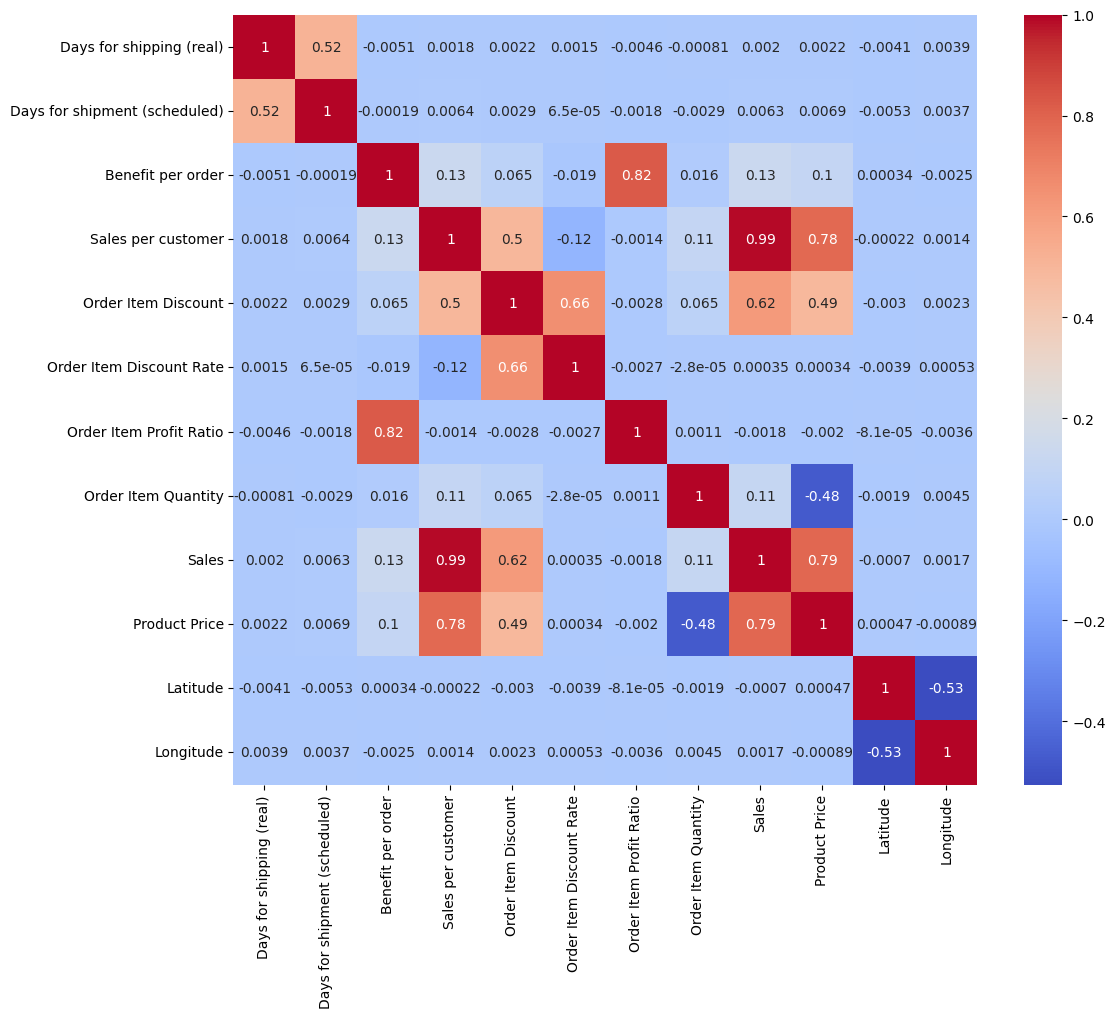

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Benefit per order',
    'Sales per customer',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Profit Ratio',
    'Order Item Quantity',
    'Sales',
    'Product Price',
    'Latitude',
    'Longitude'
]



df_feat = df.select(numeric_cols).toPandas()

plt.figure(figsize=(12, 10))
sns.heatmap(df_feat.corr(), annot=True, cmap='coolwarm')
plt.show()

In [14]:
df = df.drop("Sales per customer")

In [15]:
df.printSchema()

root
 |-- Type: string (nullable = true)
 |-- Days for shipping (real): integer (nullable = true)
 |-- Days for shipment (scheduled): integer (nullable = true)
 |-- Benefit per order: double (nullable = true)
 |-- Delivery Status: string (nullable = true)
 |-- Late_delivery_risk: integer (nullable = true)
 |-- Category Id: integer (nullable = true)
 |-- Category Name: string (nullable = true)
 |-- Customer City: string (nullable = true)
 |-- Customer Country: string (nullable = true)
 |-- Customer Fname: string (nullable = true)
 |-- Customer Id: integer (nullable = true)
 |-- Customer Lname: string (nullable = true)
 |-- Customer Segment: string (nullable = true)
 |-- Customer State: string (nullable = true)
 |-- Customer Street: string (nullable = true)
 |-- Customer Zipcode: integer (nullable = true)
 |-- Department Id: integer (nullable = true)
 |-- Department Name: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Market

In [16]:
more_columns_to_drop = [
    'Delivery Status',
    'Days for shipping (real)',
    'shipping date (DateOrders)',
    'Order Status',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Id',
    'Order Id',
    'Order Item Id',
    'Product Card Id',
    'Product Name',
    'Product Image',
    'Category Name',
    'Department Name'
]


df = df.drop(*more_columns_to_drop)

In [17]:
df.printSchema()

root
 |-- Type: string (nullable = true)
 |-- Days for shipment (scheduled): integer (nullable = true)
 |-- Benefit per order: double (nullable = true)
 |-- Late_delivery_risk: integer (nullable = true)
 |-- Category Id: integer (nullable = true)
 |-- Customer City: string (nullable = true)
 |-- Customer Country: string (nullable = true)
 |-- Customer Segment: string (nullable = true)
 |-- Customer State: string (nullable = true)
 |-- Customer Zipcode: integer (nullable = true)
 |-- Department Id: integer (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Market: string (nullable = true)
 |-- Order City: string (nullable = true)
 |-- Order Country: string (nullable = true)
 |-- order date (DateOrders): string (nullable = true)
 |-- Order Item Discount: double (nullable = true)
 |-- Order Item Discount Rate: double (nullable = true)
 |-- Order Item Profit Ratio: double (nullable = true)
 |-- Order Item Quantity: integer (nullable = tr

In [18]:
df = df.drop('Order Zipcode')

# Création de la colonne distance

In [19]:
delivery_location_columns = df.select("Order City", "Order State", "Order Country")

In [ ]:
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()

GEOAPIFY_API_KEY = os.getenv('GEOAPIFY_API_KEY')

delivery_location_columns = delivery_location_columns.toPandas()

delivery_location_columns['location_str'] = (
    delivery_location_columns['Order City'] + ', ' + 
    delivery_location_columns['Order State'] + ', ' + 
    delivery_location_columns['Order Country']
)

unique_strs = delivery_location_columns['location_str'].unique()

def geocode_location(loc_str):
    try:
        url = f"https://api.geoapify.com/v1/geocode/search?text={loc_str}&lang=es&apiKey={GEOAPIFY_API_KEY}"
        response = requests.get(url, timeout=15)
        
        if response.status_code == 200:
            data = response.json()
            if data['features']:
                coords = data['features'][0]['geometry']['coordinates']
                return loc_str, (coords[1], coords[0])
        return loc_str, (None, None)
    except Exception as e:
        return loc_str, (None, None)

coords_dict = {}

with ThreadPoolExecutor(max_workers=5) as executor:
    futures = {executor.submit(geocode_location, loc): loc for loc in unique_strs}
    
    for future in tqdm(as_completed(futures), total=len(unique_strs)):
        loc_str, coords = future.result()
        coords_dict[loc_str] = coords

delivery_location_columns[['dest_lat', 'dest_lon']] = pd.DataFrame(
    delivery_location_columns['location_str'].map(coords_dict).tolist(),
    index=delivery_location_columns.index
)

successful = delivery_location_columns['dest_lat'].notna().sum()
failed = delivery_location_columns['dest_lat'].isna().sum()
print(f"\nGeocoding complete!")
print(f"Successful: {successful} ({successful/len(delivery_location_columns)*100:.2f}%)")
print(f"Failed: {failed} ({failed/len(delivery_location_columns)*100:.2f}%)")

delivery_location_columns.to_csv('geocoded_locations.csv', index=False)

In [20]:
delivery_location_columns = spark.read.csv('geocoded_locations.csv', header = True, inferSchema= True)

In [21]:
delivery_location_columns = delivery_location_columns.drop('Order City', 'Order State', 'Order Country', 'location_str')

In [22]:
delivery_location_columns

DataFrame[dest_lat: double, dest_lon: double]

In [ ]:
#delivery_location_columns.drop(columns=['Order City', 'Order State', 'Order Country', 'location_str'], inplace=True)

In [ ]:
#delivery_location_columns = spark.createDataFrame(delivery_location_columns)

In [23]:
df_with_id = df.withColumn("row_id", F.monotonically_increasing_id())
delivery_location_columns_with_id = delivery_location_columns.withColumn("row_id", F.monotonically_increasing_id())

df = df_with_id.join(delivery_location_columns_with_id, on="row_id", how="inner").drop("row_id")

In [24]:
import math
from pyspark.sql.types import DoubleType

def haversine_distance(lat1, lon1, lat2, lon2):
    if None in [lat1, lon1, lat2, lon2]:
        return None
    else:
        R = 6371.0

        lat1_rad = math.radians(lat1)
        lon1_rad = math.radians(lon1)
        lat2_rad = math.radians(lat2)
        lon2_rad = math.radians(lon2)
    
        dlat = lat2_rad - lat1_rad
        dlon = lon2_rad - lon1_rad
        
        a = math.sin(dlat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon / 2)**2
        c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
        
        distance = R * c
        
        return distance

haversine_udf = F.udf(haversine_distance, DoubleType())

df = df.withColumn(
    "distance", 
    haversine_udf(F.col("Latitude"), F.col("Longitude"), F.col("dest_lat"), F.col("dest_lon"))
)

In [25]:
df = df.drop('Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Name', 'Latitude', 'Longitude', 'Order City', 'Order Country', 'Order Customer Id', 'order date' 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Region', 'Order State', 'Order Zipcode', 'Product Description', 'Product Image', 'Product Name', 'Product', 'dest_lat', 'dest_lon')

In [26]:
df.printSchema()

root
 |-- Type: string (nullable = true)
 |-- Days for shipment (scheduled): integer (nullable = true)
 |-- Benefit per order: double (nullable = true)
 |-- Late_delivery_risk: integer (nullable = true)
 |-- Category Id: integer (nullable = true)
 |-- Department Id: integer (nullable = true)
 |-- Market: string (nullable = true)
 |-- order date (DateOrders): string (nullable = true)
 |-- Order Item Discount Rate: double (nullable = true)
 |-- Order Item Profit Ratio: double (nullable = true)
 |-- Order Item Quantity: integer (nullable = true)
 |-- Sales: double (nullable = true)
 |-- Product Price: double (nullable = true)
 |-- Shipping Mode: string (nullable = true)
 |-- distance: double (nullable = true)



# Détection des outliers

In [27]:
outlier_cols = [
    'Days for shipment (scheduled)',
    'Benefit per order',
    'Order Item Discount Rate',
    'Order Item Profit Ratio',
    'Order Item Quantity',
    'Sales',
    'Product Price'
]

for col in outlier_cols:
   
    Q1, Q3 = df.approxQuantile(col, [0.25, 0.75], 0.01)
    IQR = Q3 - Q1

    
    lower= Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = df.filter((df[col] < lower) | (df[col] > upper)).count()

    print(f"{col}: {outlier_count} outliers")

Days for shipment (scheduled): 0 outliers
Benefit per order: 3636 outliers
Order Item Discount Rate: 0 outliers
Order Item Profit Ratio: 3204 outliers
Order Item Quantity: 0 outliers
Sales: 112 outliers
Product Price: 5871 outliers


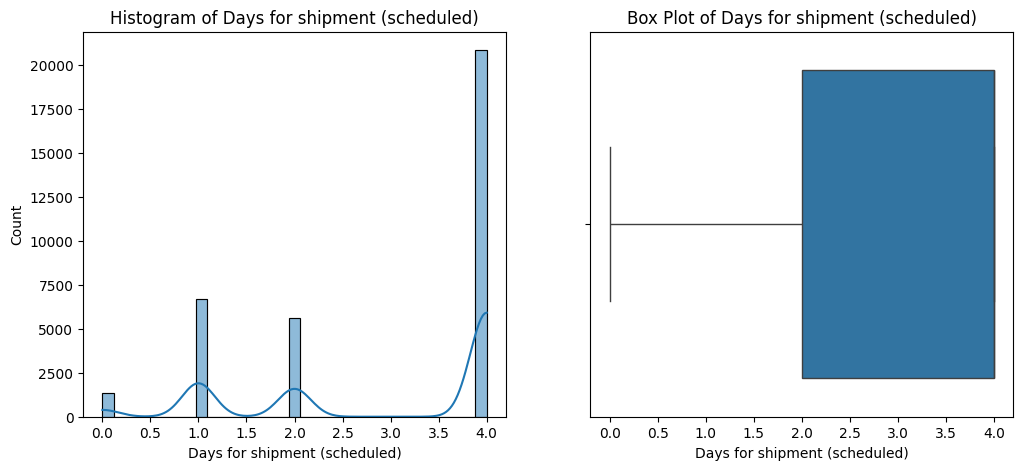

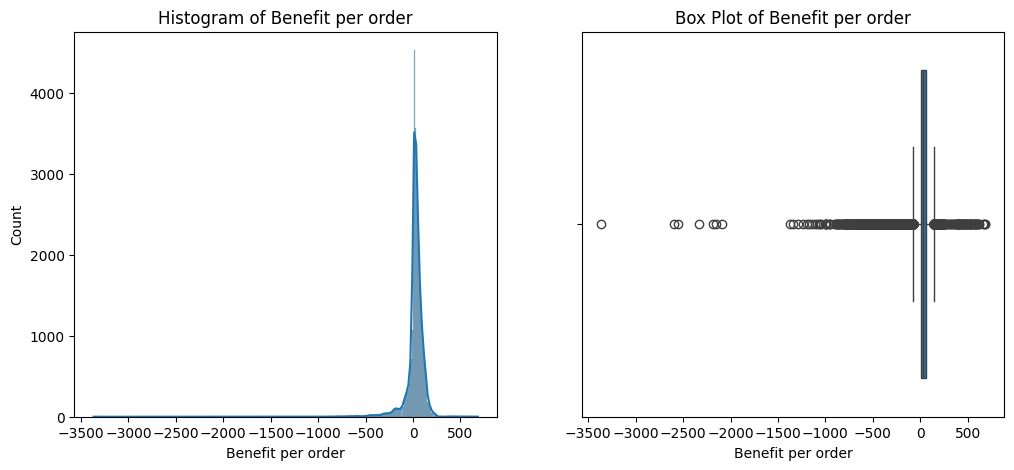

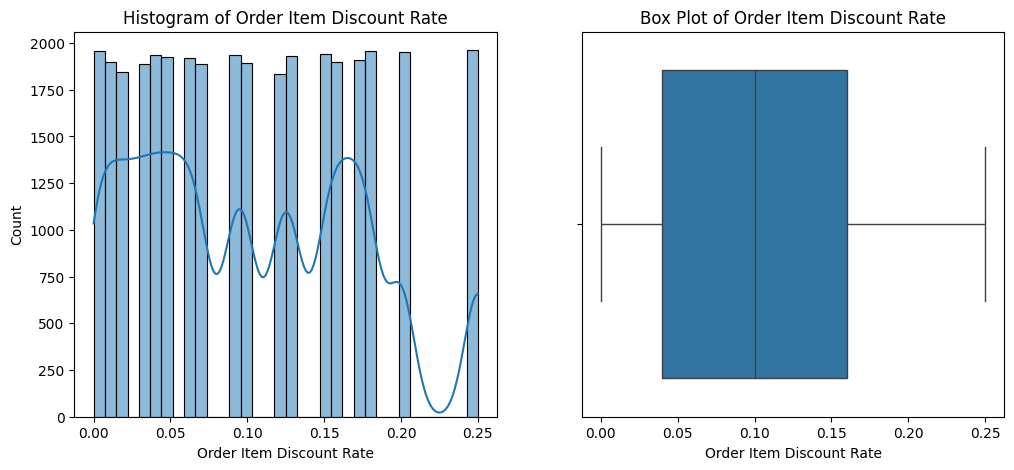

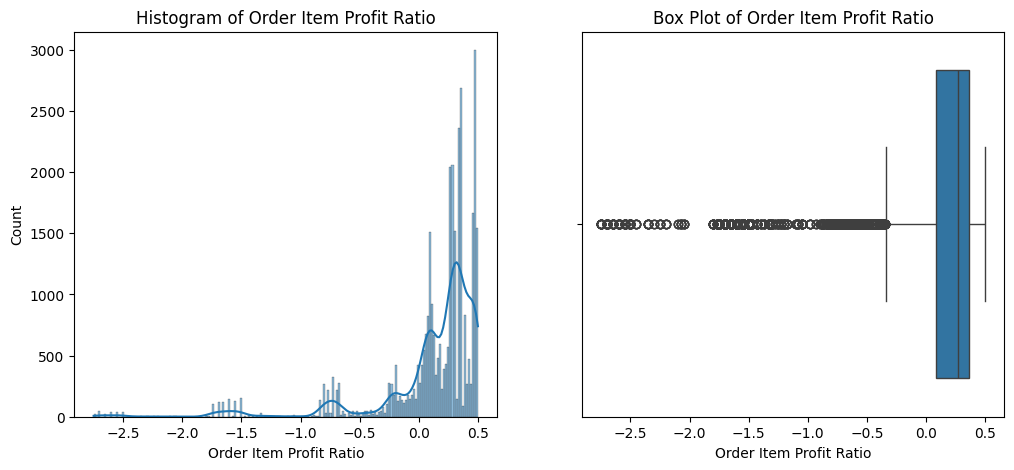

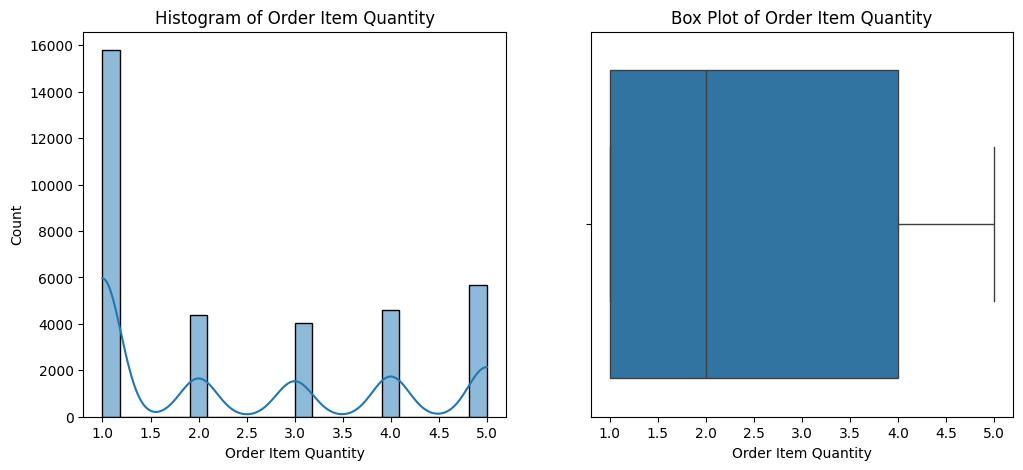

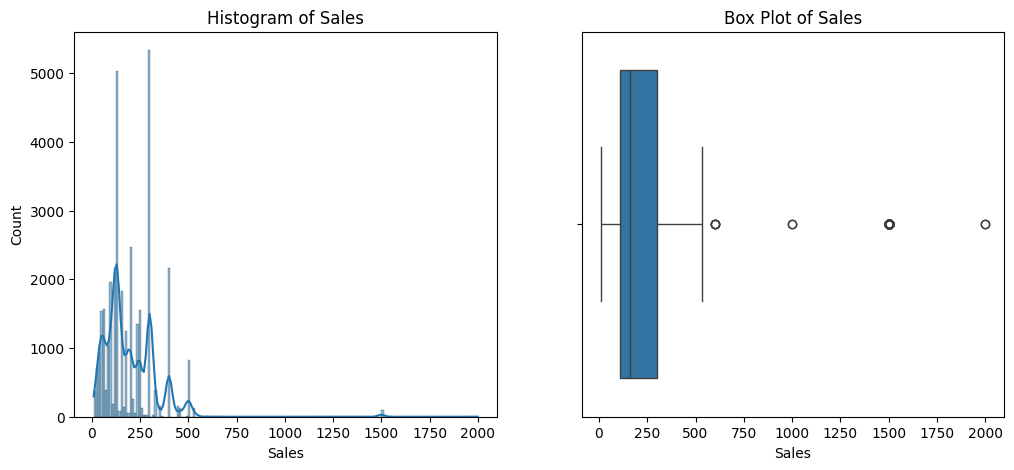

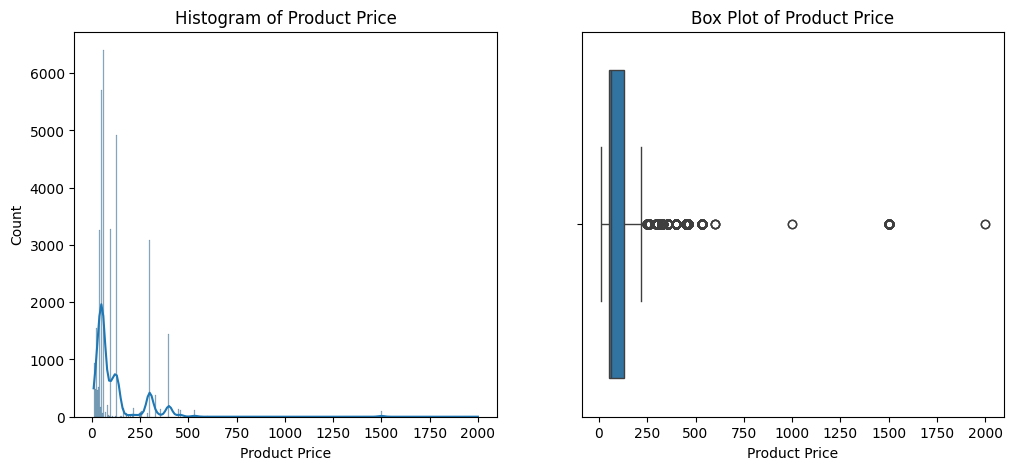

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt


continuous_and_discrete_features = [
    'Days for shipment (scheduled)',
    'Benefit per order',
    'Order Item Discount Rate',
    'Order Item Profit Ratio',
    'Order Item Quantity',
    'Sales',
    'Product Price'
]


for col in continuous_and_discrete_features:
    
    pd_series = df.select(col).toPandas()[col]


    plt.figure(figsize=(12, 5))
    
    # Plot 1: Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(pd_series, kde=True)
    plt.title(f'Histogram of {col}')
    
    # Plot 2: Box Plot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=pd_series)
    plt.title(f'Box Plot of {col}')
    
    plt.show()        

In [ ]:
#columns to add: is_zip_code_missing, city_risk_encoded, state_risk_encoded, 

In [29]:
columns_to_keep = [
    'Days for shipment (scheduled)', 
    'Category Id',                              
    'Order Item Quantity',                             
    'Shipping Mode',                  
    'distance',                     
    'Late_delivery_risk'              
]

df = df.select(columns_to_keep)

In [30]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="Shipping Mode", outputCol="ShippingMode_index")
df = indexer.fit(df).transform(df)

df.select("Shipping Mode", "ShippingMode_index").show(5)


+--------------+------------------+
| Shipping Mode|ShippingMode_index|
+--------------+------------------+
|Standard Class|               0.0|
|Standard Class|               0.0|
|Standard Class|               0.0|
|Standard Class|               0.0|
|Standard Class|               0.0|
+--------------+------------------+
only showing top 5 rows


In [31]:
df.select("Shipping Mode", "ShippingMode_index").show(100)

+--------------+------------------+
| Shipping Mode|ShippingMode_index|
+--------------+------------------+
|Standard Class|               0.0|
|Standard Class|               0.0|
|Standard Class|               0.0|
|Standard Class|               0.0|
|Standard Class|               0.0|
|Standard Class|               0.0|
|   First Class|               1.0|
|   First Class|               1.0|
|  Second Class|               2.0|
|   First Class|               1.0|
|  Second Class|               2.0|
|  Second Class|               2.0|
|  Second Class|               2.0|
|   First Class|               1.0|
|   First Class|               1.0|
|   First Class|               1.0|
|  Second Class|               2.0|
|   First Class|               1.0|
|   First Class|               1.0|
|      Same Day|               3.0|
|      Same Day|               3.0|
|Standard Class|               0.0|
|  Second Class|               2.0|
|  Second Class|               2.0|
|  Second Class|            

In [32]:
df = df.drop('Shipping Mode')

# Construction du Pipeline

In [34]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier


feature_cols = [
    'Days for shipment (scheduled)', 
    'Category Id',                              
    'Order Item Quantity',                             
    'ShippingMode_index',                  
    'distance'
]

df = df.na.fill(0, feature_cols)


assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")


classifier = RandomForestClassifier(
    featuresCol="features",
    labelCol="Late_delivery_risk",
    predictionCol="prediction"
)


pipeline = Pipeline(stages=[assembler, classifier])


train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)


model = pipeline.fit(train_data)

predictions = model.transform(test_data)

Py4JJavaError: An error occurred while calling o49143.fit.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 2 in stage 4223.0 failed 1 times, most recent failure: Lost task 2.0 in stage 4223.0 (TID 32439) (DESKTOP-32JKG5K executor driver): org.apache.spark.SparkException: Python worker exited unexpectedly (crashed). Consider setting 'spark.sql.execution.pyspark.udf.faulthandler.enabled' or'spark.python.worker.faulthandler.enabled' configuration to 'true' for the better Python traceback.
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:621)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:599)
	at scala.runtime.AbstractPartialFunction.apply(AbstractPartialFunction.scala:35)
	at org.apache.spark.sql.execution.python.BasePythonUDFRunner$$anon$2.read(PythonUDFRunner.scala:112)
	at org.apache.spark.sql.execution.python.BasePythonUDFRunner$$anon$2.re